In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
np.float = np.float64
import sys
sys.path.append("/n/home07/yitians/fermi/NPTFit/NPTFit")

import npll

In [2]:
import sys
#from nptfit_func import *

sys.path.append("..")
# from utils import create_mask as cm
# from models.templates import NFWTemplate, LorimerDiskTemplate
# from models.psf import KingPSF
from utils.utils import find_max_point

import healpy as hp
import pickle
from tqdm import tqdm

#from NPTFit import npll

import os
import sys
from tqdm import tqdm

import jax
from jax import jit
import jax.numpy as jnp

# import numpy as np
import healpy as hp
import pickle
from functools import partial

os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"
print(jax.devices())

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../notebooks/matplotlibrc")

[CpuDevice(id=0)]


In [ ]:
sys.path.append("..")
from models.np_model import NPModel

In [ ]:
from fit_np_to_np.ll import ll_justSps_nosum

In [ ]:
npmodel = NPModel(
    non_poissonian=True, l_max=2,
    dif_names=["ModelO", "ModelA", "ModelF"],
    bulge_hybrid=True,
    bulge_template_names=["mcdermott2022", "mcdermott2022_bbp", "mcdermott2022_x", "macias2019", "coleman2019"],
    vary_gamma=True,
    vary_disk=True,
    ps_cat="3fgl", r_outer=25, band_mask_range=2.,
    nside=128, n_exp=1, debug_model=False,
    use_flat_exposure=True,
)

Number of pixels in ROI: 6839
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/validating/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


In [6]:
i_counts = 0
counts = jnp.array(jnp.load(f"../outputs/justSps/counts_{i_counts}.npy"), dtype=jnp.int32)
var_dict = pickle.load(open(f"../outputs/justSps/truth.p", 'rb'))

In [11]:
ll_arr = ll_justSps_nosum(npmodel, var_dict, counts, mask_fit=None)

In [12]:
np.save(f"ll_nm.npy", ll_arr)

In [ ]:
ll_full_arr = np.full_like(counts, ll_arr.min()*1.1)
ll_full_arr[~npmodel.mask_roi] = np.array(ll_arr)

## NPTFit

In [4]:
sys.path.append("..")
from utils import create_mask as cm
from models.templates import NFWTemplate, LorimerDiskTemplate
from models.psf import KingPSF
from utils.utils import find_max_point

In [5]:
# mask
nside = 128
band_mask_range = 2.
r_outer = 25.
mask_ps = hp.ud_grade(np.load(f"../data/mask_3fgl_0p8deg.npy"), nside_out=nside) > 0
mask_roi = cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=band_mask_range, mask_ring=True, inner=0, outer=r_outer, custom_mask=mask_ps)
mask_plane = cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=25,)
normalization_mask = mask_plane
mask_outer = cm.make_mask_total(nside=nside, band_mask=False, mask_ring=True, inner=0, outer=25,)

# temp
nfw_template = NFWTemplate(nside=nside)
disk_template = LorimerDiskTemplate(nside=nside)

In [9]:
from nptfit_func import *

In [10]:
# psf
kp = KingPSF()
f_ary, df_rho_div_f_ary = psf_corr(psf_r_func = kp.psf_fermi_r, num_f_bins=30)

In [12]:
run_name = 'justSps'
truth_dict = pickle.load(open(f'../outputs/{run_name}/truth.p', 'rb'))

# temp
temp_ps = {
    'gce' : nfw_template.get_NFW2_template(gamma=truth_dict['gamma_ps']),
    'dsk' : disk_template.get_template(zs=truth_dict['zs'], C=truth_dict['C']),
    #'iso' : np.ones_like(mask_outer, dtype=float),
}

# S over A
Sps_over_A_dict = {}
for k in ['dsk', 'gce']:
    s_ary = np.logspace(-1., 2., 100)
    vd = truth_dict
    theta_tmp = np.array([1., vd['n1_'+k], vd['n2_'+k], vd['n3_'+k], vd['sb1_'+k], vd['lambdas_'+k] * vd['sb1_'+k]])
    dnds_ary = dnds(s_ary, theta_tmp)
    Sps_over_A_dict[k] = np.mean(temp_ps[k][~normalization_mask]) * np.trapz(s_ary * dnds_ary, s_ary)

In [48]:
Sps_dsk_s = np.linspace(0.5, 1.5, 50)
ll_ss = []
counts_arr = []

mask = mask_roi
#save_fn = f'{run_name}_ll_ss_nm.p'
include_ps_k = ['dsk', 'gce']

pt_sum_compressed = np.full_like(temp_ps['dsk'][~mask], 1e-10, dtype=np.float64)
npt_compressed = [np.array(temp_ps[k][~mask], dtype=np.float64) for k in include_ps_k]

for i_data in tqdm(range(1)):
    ll_s = []
    fermi_data = np.load(f'../outputs/{run_name}/counts_{i_data}.npy')[~mask].astype(np.int32)
    counts_arr.append(np.sum(fermi_data))
    A = {}
    A['dsk'] = vd['Sps_dsk'] / Sps_over_A_dict['dsk']
    A['gce'] = vd['Sps_gce'] / Sps_over_A_dict['gce']
    #A['iso'] = vd['Sps_iso'] / Sps_over_A_dict['iso']
    theta = np.array([ [A[k], vd['n1_'+k], vd['n2_'+k], vd['n3_'+k], vd['sb1_'+k], vd['sb1_'+k]*vd['lambdas_'+k]] for k in include_ps_k ], dtype=np.float64)
    ll = npll.log_like_arr(pt_sum_compressed, theta, f_ary, df_rho_div_f_ary, npt_compressed, fermi_data)
#pickle.dump(ll_ss, open(save_fn, 'wb'))

100%|██████████| 1/1 [00:00<00:00,  8.24it/s]


In [21]:
mask_roi = np.load("mask_roi.npy")
nm = np.load("nm.npy")

In [49]:
ll_full_arr_npft = np.full((196608,), np.min(ll)*1.1)
ll_full_arr_npft[~mask_roi] = np.array(ll)

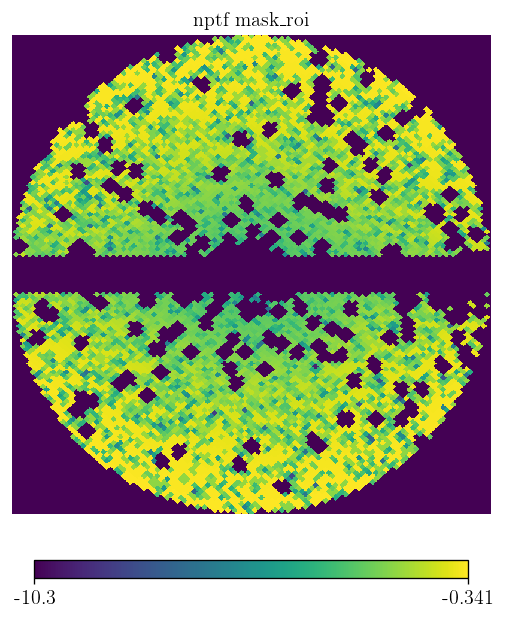

In [50]:
hp.cartview(ll_full_arr_npft, latra=[-25, 25], lonra=[-25, 25], title='nptf mask_roi')

In [54]:
ll_full_arr = np.full((196608,), -11.)
ll_mask_roi_jax = np.load("ll_mask_roi.npy")
ll_full_arr[~mask_roi] = ll_mask_roi_jax

ll_diff = ll_full_arr_npft.copy()
ll_diff -= ll_full_arr

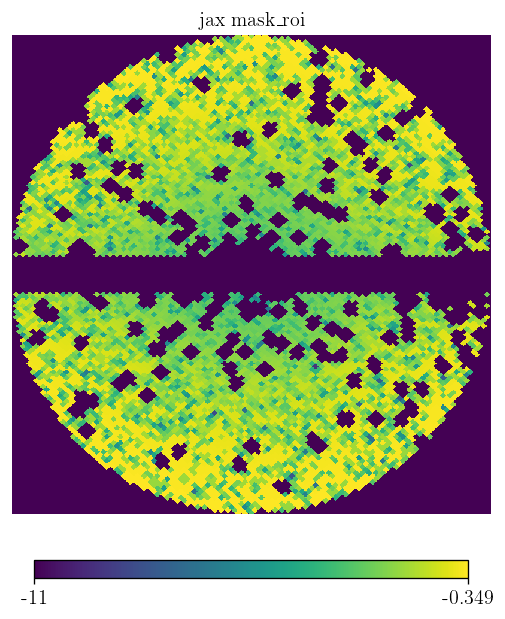

In [55]:
hp.cartview(ll_full_arr, latra=[-25, 25], lonra=[-25, 25], title='jax mask_roi')

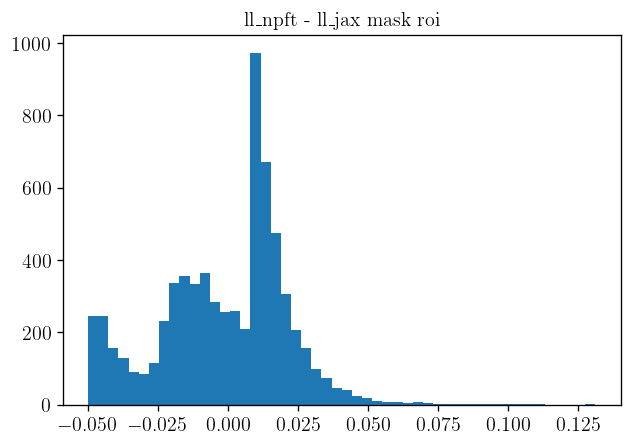

In [57]:
plt.hist(ll_diff[~mask_roi], bins=50)
plt.title('ll_npft - ll_jax mask roi');

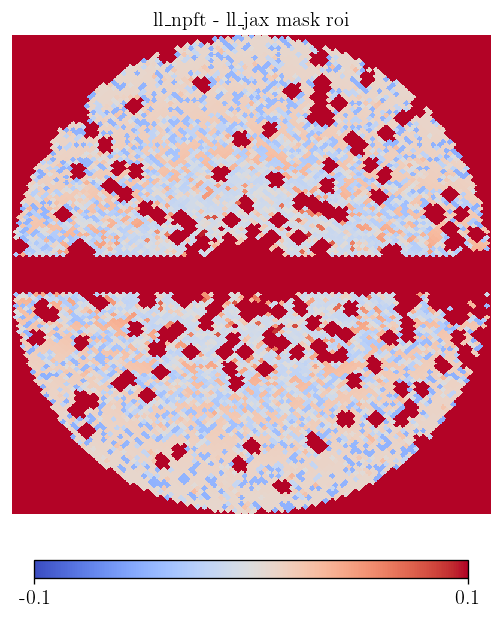

In [58]:
hp.cartview(ll_diff, latra=[-25, 25], lonra=[-25, 25], title='ll_npft - ll_jax mask roi', min=-.1, max=.1, cmap='coolwarm')

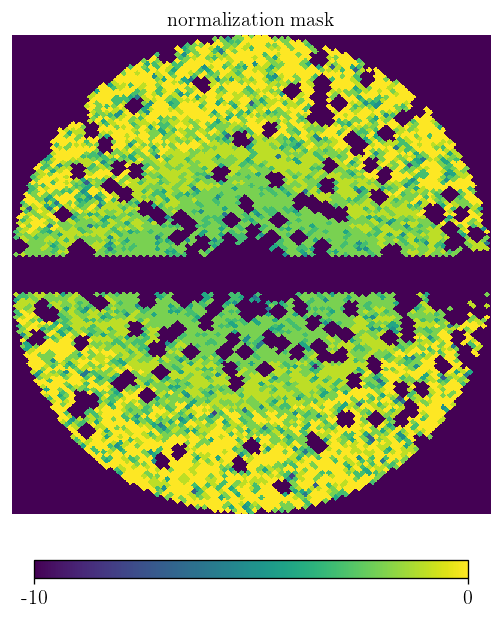

In [25]:
hp.cartview(ll_full_arr, latra=[-25, 25], lonra=[-25, 25], title='normalization mask')

In [ ]:
ll_full_arr = np.full_like(counts, ll_arr.min()*1.1)
ll_full_arr[~npmodel.normalization_mask] = np.array(ll_arr)